# Anatomical Structure Segmentation in Chest Radiographs (JSRT)

End-to-end training of a fully convolutional network for binary semantic
segmentation of three anatomical structures, clavicles, lungs and heart,
on the JSRT chest radiograph dataset.

The dataset comprises 154 chest radiographs (with per-image masks for each
anatomical target). Each task is treated independently as foreground /
background segmentation; performance is reported via per-image
**Intersection over Union (Jaccard)** and the **Sørensen–Dice (F1)**
coefficient, mean ± standard deviation across the test split.

Architecture: FCN with an ImageNet-pretrained AlexNet backbone, with optional
shallow/deep feature fusion (FCN-8s-style skip connections adapted to AlexNet's
depth).


In [11]:
import os
import time

import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from skimage import io, transform
from sklearn import metrics as sk_metrics
from torch import nn, optim
from torch.backends import cudnn
from torch.utils import data
from torch.utils.data import DataLoader
from torchvision import models

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **_kwargs):
        return iterable

cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [12]:
import urllib.request
import zipfile

DATA_ROOT = "./jsrt"
ARCHIVE = "jsrt.zip"
URL = "https://www.dropbox.com/sh/grjpx4oeacg32c0/AAAPpBgABESAWz-se4eCP9-Ya?dl=1"

if not os.path.exists(DATA_ROOT) or not os.listdir(DATA_ROOT):
    if not os.path.exists(ARCHIVE):
        print(f"Downloading {ARCHIVE}...")
        urllib.request.urlretrieve(URL, ARCHIVE)
    print(f"Extracting to {DATA_ROOT}/...")
    os.makedirs(DATA_ROOT, exist_ok=True)
    with zipfile.ZipFile(ARCHIVE) as zf:
        zf.extractall(DATA_ROOT)

print(os.listdir(DATA_ROOT)[:10])


['lungs_train.txt', 'heart_test.txt', 'images', 'ground_truths', 'heart_train.txt', 'clavicles_test.txt', 'lungs_test.txt', 'clavicles_train.txt']


In [13]:
config = {
    # Active task — alternatives: 'lungs', 'heart'.
    "task": "clavicles",
    "dataset": "jsrt",
    "n_classes": 2,
    "epoch_num": 20,
    "batch_size": 8,
    # 0 keeps the loader in the main process — required when ListDataset is
    # defined inside the notebook (spawn-based workers can't pickle classes
    # from __main__ on macOS / Windows). Bump to 2-3 on Colab/Linux for speed.
    "num_workers": 0,
    "image_size": (256, 256),
    "lr": 1e-4,
    "weight_decay": 5e-4,
    "momentum": 0.9,
    "show_freq": 5,
    "pretrained": True,
    "skip": True,
}
config


{'task': 'clavicles',
 'dataset': 'jsrt',
 'n_classes': 2,
 'epoch_num': 20,
 'batch_size': 8,
 'num_workers': 0,
 'image_size': (256, 256),
 'lr': 0.0001,
 'weight_decay': 0.0005,
 'momentum': 0.9,
 'show_freq': 5,
 'pretrained': True,
 'skip': True}

In [14]:
class ListDataset(data.Dataset):
    """Image / mask pair reader driven by a text-file manifest.

    Parameters
    ----------
    root : str
        Top-level data directory (e.g. './' if the dataset is unzipped to './jsrt/').
    mode : {'train', 'test'}
        Manifest split to load.
    dataset : str
        Sub-directory of `root` (e.g. 'jsrt').
    task : str
        Anatomical structure to segment (e.g. 'clavicles').
    resize_to : tuple of int, default (256, 256)
        Target (H, W) for both images and masks.
    in_channels : int, default 1
        JSRT radiographs are grayscale.
    num_classes : int, default 2
        When equal to 2, mask values are clamped to {0, 1}.
    """

    def __init__(self, root, mode, dataset, task,
                 resize_to=(256, 256), in_channels=1, num_classes=2):
        self.root = root
        self.mode = mode
        self.dataset = dataset
        self.task = task
        self.resize_to = resize_to
        self.in_channels = in_channels
        self.num_classes = num_classes

        self.imgs = self._make_dataset()
        if len(self.imgs) == 0:
            raise RuntimeError(f"Found 0 images for task={task!r} mode={mode!r}.")

    def _make_dataset(self):
        assert self.mode in ("train", "test"), f"unknown mode: {self.mode}"
        self.img_path = os.path.join(self.root, self.dataset, "images")
        self.msk_path = os.path.join(self.root, self.dataset, "ground_truths", self.task)
        manifest = os.path.join(self.root, self.dataset, f"{self.task}_{self.mode}.txt")
        with open(manifest) as fh:
            return [line.strip() for line in fh.readlines() if line.strip()]

    def __getitem__(self, index):
        f = self.imgs[index]
        img = io.imread(os.path.join(self.img_path, f))
        msk = io.imread(os.path.join(self.msk_path, f))

        # Bilinear for the image, nearest-neighbour for the mask.
        img = transform.resize(img, self.resize_to, preserve_range=True, order=1)
        msk = transform.resize(msk, self.resize_to, preserve_range=True, order=0)

        img = img.astype(np.float32)
        msk = msk.astype(np.int64)
        if self.num_classes == 2:
            msk[msk > 0] = 1

        # Per-channel z-score normalisation.
        if self.in_channels == 1:
            img = (img - img.mean()) / img.std()
        else:
            for c in range(img.shape[2]):
                img[:, :, c] = (img[:, :, c] - img[:, :, c].mean()) / img[:, :, c].std()

        # Channel-first tensor layout.
        if self.in_channels == 1:
            img = np.expand_dims(img, axis=0)
        else:
            img = np.transpose(img, (2, 0, 1))

        return torch.from_numpy(img), torch.from_numpy(msk)

    def __len__(self):
        return len(self.imgs)


In [15]:
def evaluate(predictions, labels):
    """Per-sample IoU (Jaccard) and Dice (F1) for binary masks."""
    iou_list, f1_list = [], []
    for prd, lab in zip(predictions, labels):
        iou_list.append(sk_metrics.jaccard_score(lab.ravel(), prd.ravel()))
        f1_list.append(sk_metrics.f1_score(lab.ravel(), prd.ravel()))
    return np.asarray(iou_list), np.asarray(f1_list)


def initialize_weights(*models_to_init):
    """Kaiming-normal for Conv2d/Linear; ones+zeros for BatchNorm2d."""
    for model in models_to_init:
        for module in model.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(module.weight)
                if module.bias is not None:
                    module.bias.data.zero_()
            elif isinstance(module, nn.BatchNorm2d):
                module.weight.data.fill_(1)
                module.bias.data.zero_()


In [16]:
class FCN_AlexNet(nn.Module):
    """FCN with an AlexNet backbone and optional shallow/deep feature fusion.

    `skip=False`: a single backbone produces a coarse H/32 x W/32 feature map
    which is bilinearly upsampled to the input resolution before a small
    convolutional classifier head produces per-pixel logits.

    `skip=True`: mid-level (192-channel) and deep (256-channel) feature maps
    are independently upsampled to the input size and concatenated along the
    channel dimension before the classifier — an FCN-8s-style fusion adapted
    to AlexNet's depth.

    For 1-channel inputs (e.g. grayscale medical images), the original
    11x11 stem is replaced with a 3x3 convolution that accepts
    `input_channels` input maps.
    """

    def __init__(self, input_channels, num_classes, pretrained=False, skip=False):
        super().__init__()
        self.skip = skip
        feat = models.alexnet(pretrained=pretrained, progress=False).features

        if skip:
            self.backbone1 = nn.Sequential(
                nn.Conv2d(input_channels, 64, kernel_size=(3, 3), stride=(1, 1),
                          padding=(1, 1), bias=False),
                feat[1], feat[2], feat[3], feat[4], feat[5],
            )
            self.backbone2 = nn.Sequential(
                feat[6], feat[7], feat[8], feat[9],
                feat[10], feat[11], feat[12],
            )
            # 192 (mid) + 256 (deep) = 448 channels after concat.
            self.classifier = nn.Sequential(
                nn.Conv2d(256 + 192, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Dropout2d(0.5),
                nn.Conv2d(64, num_classes, kernel_size=3, padding=1),
            )
        else:
            self.backbone = models.alexnet(pretrained=pretrained, progress=False).features
            self.classifier = nn.Sequential(
                nn.Conv2d(256, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Dropout2d(0.5),
                nn.Conv2d(64, num_classes, kernel_size=3, padding=1),
            )

        if not pretrained:
            initialize_weights(self)

    def forward(self, x):
        target_size = x.size()[2:]
        if self.skip:
            feat1 = self.backbone1(x)
            feat2 = self.backbone2(feat1)
            feat = torch.cat(
                [
                    F.interpolate(feat1, target_size, mode="bilinear", align_corners=False),
                    F.interpolate(feat2, target_size, mode="bilinear", align_corners=False),
                ],
                dim=1,
            )
        else:
            feat = self.backbone(x)
            feat = F.interpolate(feat, target_size, mode="bilinear", align_corners=False)
        return self.classifier(feat)


In [17]:
def train(loader, net, criterion, optimizer, epoch, device):
    tic = time.time()
    net.train()

    losses = []
    labs_all, prds_all = [], []

    for inps, labs in tqdm(loader, desc=f"train [{epoch}]", leave=False):
        # Casting to device.
        inps = inps.to(device)
        labs = labs.to(device)

        # Forwarding.
        optimizer.zero_grad()
        outs = net(inps)

        # Computing loss.
        loss = criterion(
            outs.view(outs.size(0), outs.size(1), -1),
            labs.view(labs.size(0), -1),
        )

        loss.backward()
        optimizer.step()

        prds = outs.data.max(1)[1].squeeze_(1).squeeze(0).cpu().numpy()
        labs_all.append(labs.detach().data.squeeze(0).cpu().numpy())
        prds_all.append(prds)
        losses.append(loss.data.item())

    losses = np.asarray(losses)
    iou, f1 = evaluate(prds_all, labs_all)

    print("-" * 67)
    print(
        "[epoch %d] [train loss %.4f +/- %.4f] [iou %.4f +/- %.4f] "
        "[f1 %.4f +/- %.4f] [time %.2fs]"
        % (
            epoch, losses.mean(), losses.std(),
            iou.mean(), iou.std(), f1.mean(), f1.std(),
            time.time() - tic,
        )
    )
    print("-" * 67)
    return {"loss": losses.mean(), "iou": iou.mean(), "f1": f1.mean()}


def test(loader, net, criterion, epoch, device, show_freq=5, show_n=4):
    tic = time.time()
    net.eval()

    losses = []
    labs_all, prds_all = [], []

    with torch.no_grad():
        for i, (inps, labs) in enumerate(tqdm(loader, desc=f" test [{epoch}]", leave=False)):
            # Casting to device.
            inps = inps.to(device)
            labs = labs.to(device)

            # Forwarding.
            outs = net(inps)

            # Computing loss.
            loss = criterion(
                outs.view(outs.size(0), outs.size(1), -1),
                labs.view(labs.size(0), -1),
            )

            prds = outs.data.max(1)[1].squeeze_(1).squeeze(0).cpu().numpy()
            labs_all.append(labs.detach().data.squeeze(0).cpu().numpy())
            prds_all.append(prds)
            losses.append(loss.data.item())

            if i < show_n and epoch % show_freq == 0:
                fig, ax = plt.subplots(1, 3, figsize=(15, 5))
                ax[0].imshow(inps.detach().cpu().numpy().squeeze(), cmap="gray")
                ax[0].set_title("Image")
                ax[1].imshow(labs.detach().data.squeeze(0).cpu().numpy().squeeze())
                ax[1].set_title("Label")
                ax[2].imshow(prds.squeeze())
                ax[2].set_title("Prediction")
                for a in ax:
                    a.set_xticks([]); a.set_yticks([])
                fig.suptitle(f"epoch {epoch} — sample {i}")
                plt.show()

    losses = np.asarray(losses)
    iou, f1 = evaluate(prds_all, labs_all)

    print("-" * 67)
    print(
        "[epoch %d] [ test loss %.4f +/- %.4f] [iou %.4f +/- %.4f] "
        "[f1 %.4f +/- %.4f] [time %.2fs]"
        % (
            epoch, losses.mean(), losses.std(),
            iou.mean(), iou.std(), f1.mean(), f1.std(),
            time.time() - tic,
        )
    )
    print("-" * 67)
    return {"loss": losses.mean(), "iou": iou.mean(), "f1": f1.mean()}


train: 197 samples — test: 50 samples


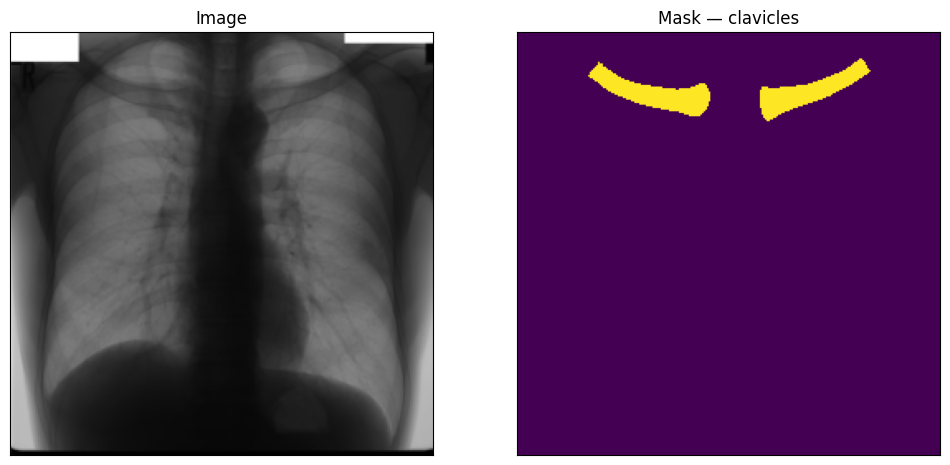

In [18]:
train_set = ListDataset(".", "train", config["dataset"], config["task"], config["image_size"])
test_set = ListDataset(".", "test", config["dataset"], config["task"], config["image_size"])

# num_workers=0 keeps the loader in the main process. Spawn-based worker
# subprocesses (default on macOS / Windows) can't pickle ListDataset because
# it's defined inside the notebook's __main__ module. On Linux/Colab, fork
# works fine — bump to 2-3 there for speed.
train_loader = DataLoader(train_set, batch_size=config["batch_size"], num_workers=0, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1, num_workers=0, shuffle=False)

print(f"train: {len(train_set)} samples — test: {len(test_set)} samples")

# Sanity check: a single training image / mask pair.
img, lab = next(iter(train_loader))
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img[0, 0].numpy(), cmap="gray"); ax[0].set_title("Image")
ax[1].imshow(lab[0].numpy()); ax[1].set_title(f"Mask — {config['task']}")
for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.show()


In [19]:
net = FCN_AlexNet(
    input_channels=1,
    num_classes=config["n_classes"],
    pretrained=config["pretrained"],
    skip=config["skip"],
).to(device)

optimizer = optim.Adam(
    [p for p in net.parameters() if p.requires_grad],
    lr=config["lr"],
    weight_decay=config["weight_decay"],
    betas=(config["momentum"], 0.999),
)
criterion = nn.CrossEntropyLoss().to(device)

n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


Trainable parameters: 2,706,370


/Users/paulezennolim/Downloads/Computer-Vision/aca23te_Ezennolim_CV2026/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/paulezennolim/Downloads/Computer-Vision/aca23te_Ezennolim_CV2026/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


train [1]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 1] [train loss 0.4397 +/- 0.1324] [iou 0.0507 +/- 0.0197] [f1 0.0958 +/- 0.0356] [time 188.84s]
-------------------------------------------------------------------


 test [1]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 1] [ test loss 0.2886 +/- 0.0070] [iou 0.0102 +/- 0.0211] [f1 0.0194 +/- 0.0392] [time 7.39s]
-------------------------------------------------------------------


train [2]:   0%|          | 0/25 [00:00<?, ?it/s]

...

 test [4]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 4] [ test loss 0.0785 +/- 0.0076] [iou 0.1686 +/- 0.1204] [f1 0.2706 +/- 0.1756] [time 7.41s]
-------------------------------------------------------------------


train [5]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 5] [train loss 0.0828 +/- 0.0088] [iou 0.2695 +/- 0.0854] [f1 0.4173 +/- 0.1080] [time 196.07s]
-------------------------------------------------------------------


 test [5]:   0%|          | 0/50 [00:00<?, ?it/s]

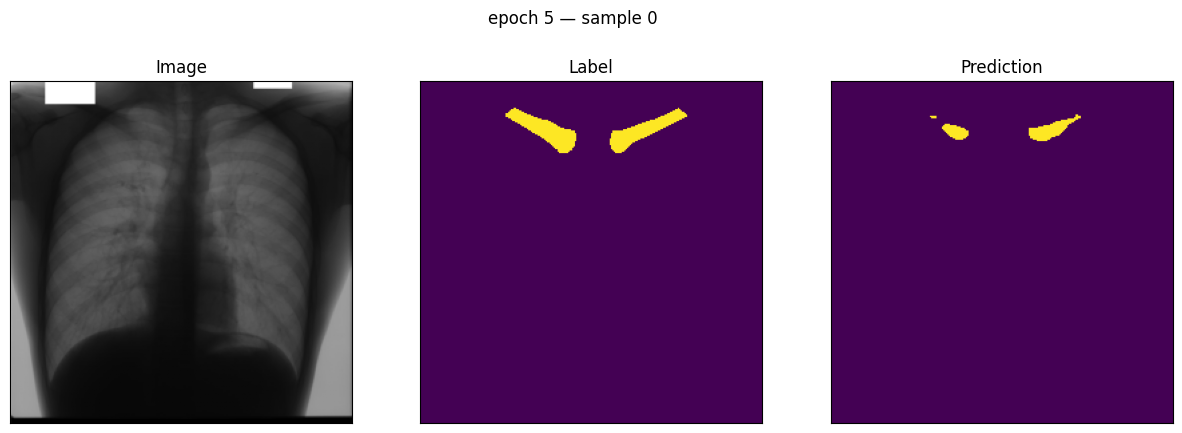

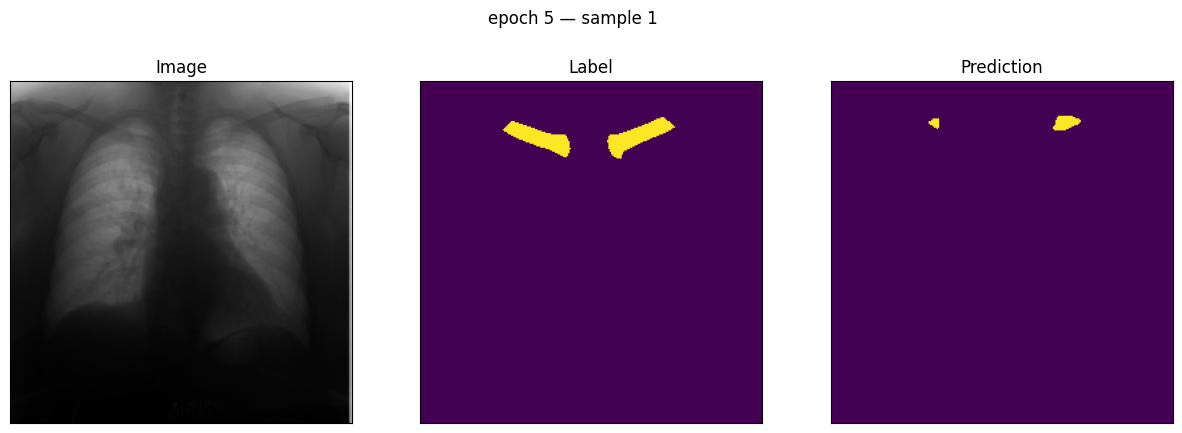

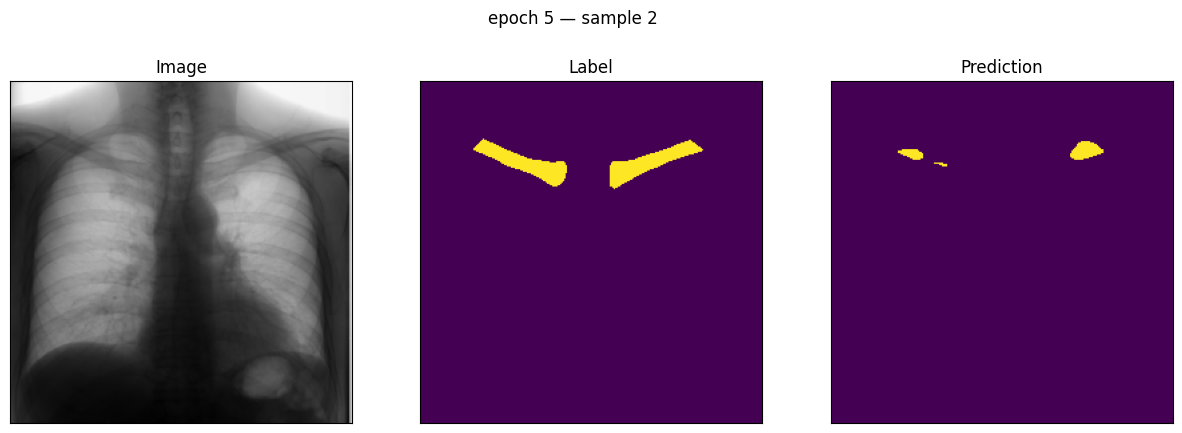

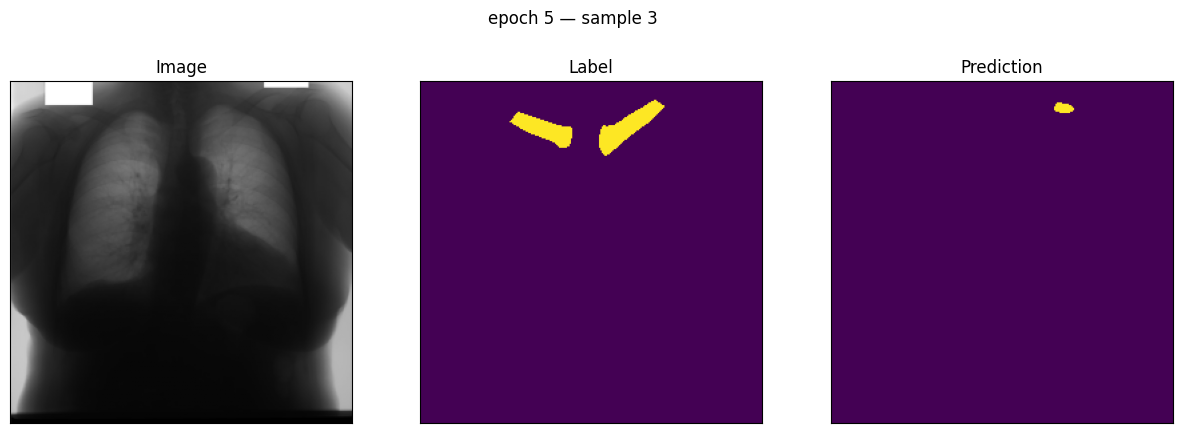

-------------------------------------------------------------------
[epoch 5] [ test loss 0.0696 +/- 0.0069] [iou 0.1795 +/- 0.1373] [f1 0.2821 +/- 0.1926] [time 8.12s]
-------------------------------------------------------------------


train [6]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 6] [train loss 0.0701 +/- 0.0075] [iou 0.3279 +/- 0.0975] [f1 0.4856 +/- 0.1133] [time 180.35s]
-------------------------------------------------------------------


 test [6]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 6] [ test loss 0.0609 +/- 0.0092] [iou 0.3369 +/- 0.1645] [f1 0.4805 +/- 0.1921] [time 7.44s]
-------------------------------------------------------------------


...

 test [9]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 9] [ test loss 0.0433 +/- 0.0102] [iou 0.3501 +/- 0.2091] [f1 0.4804 +/- 0.2496] [time 7.55s]
-------------------------------------------------------------------


train [10]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 10] [train loss 0.0455 +/- 0.0053] [iou 0.5061 +/- 0.0801] [f1 0.6682 +/- 0.0742] [time 191.29s]
-------------------------------------------------------------------


 test [10]:   0%|          | 0/50 [00:00<?, ?it/s]

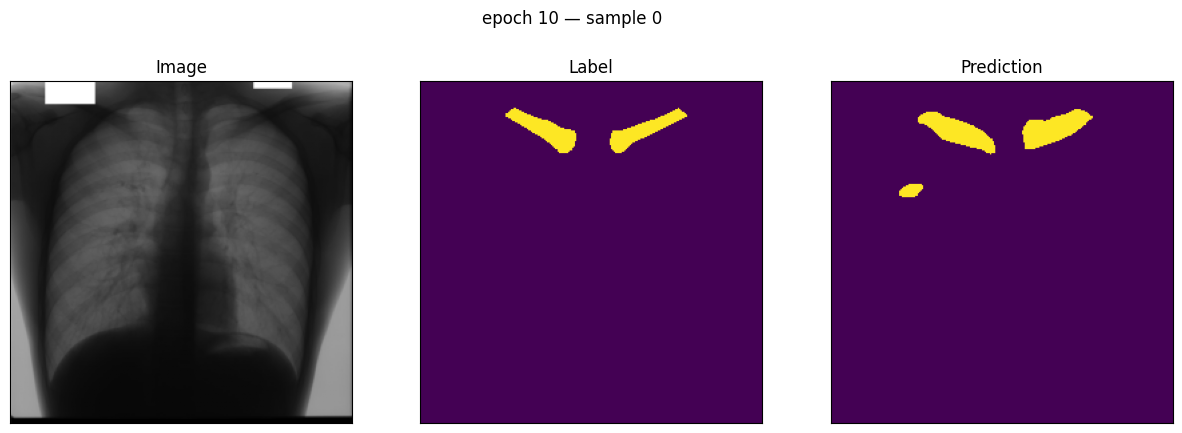

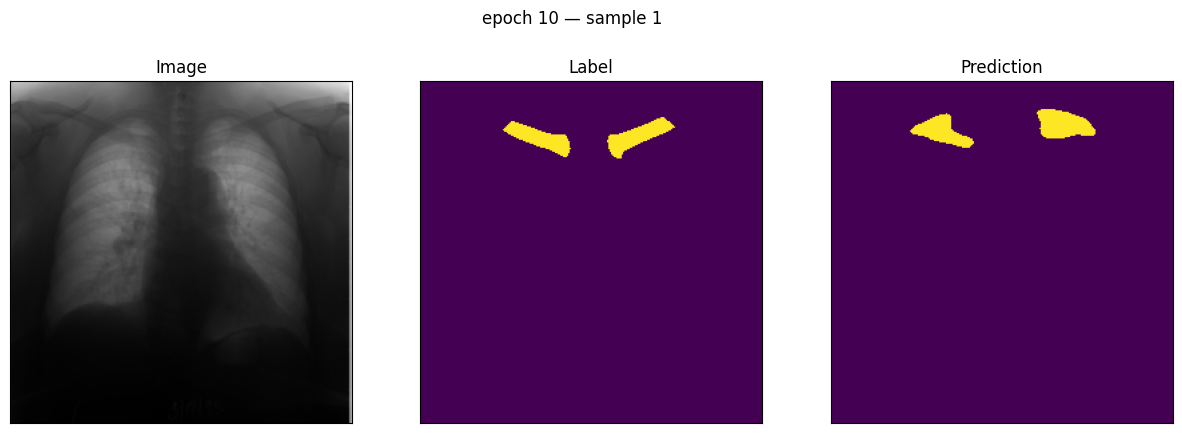

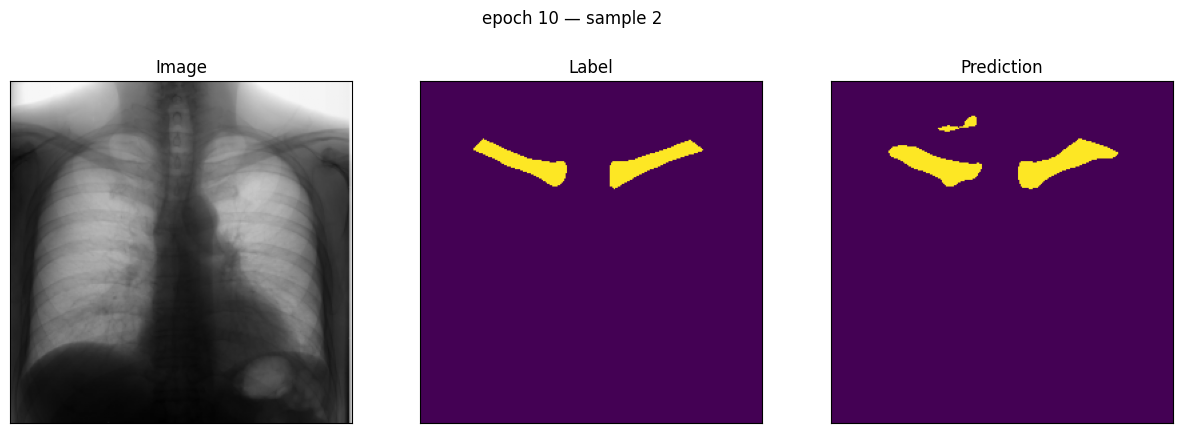

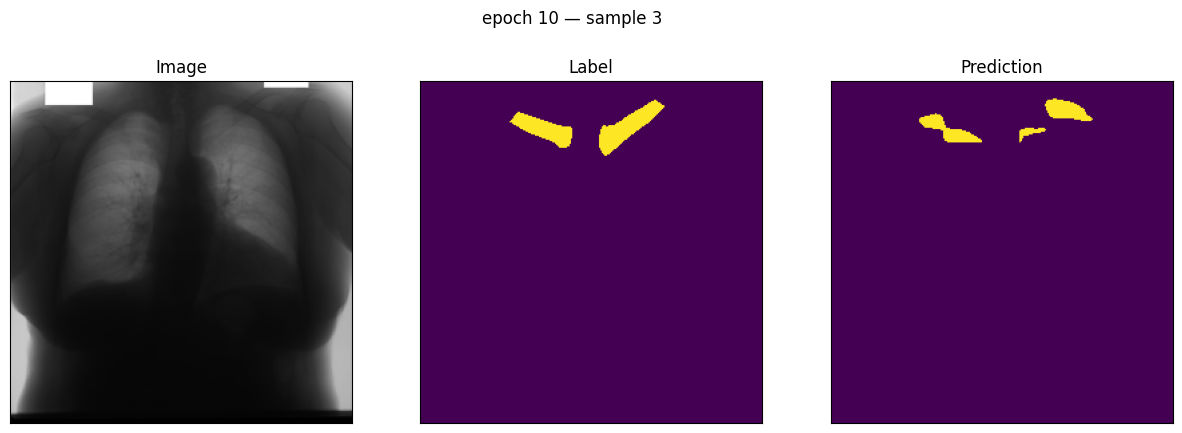

-------------------------------------------------------------------
[epoch 10] [ test loss 0.0436 +/- 0.0089] [iou 0.5489 +/- 0.1144] [f1 0.7014 +/- 0.1001] [time 8.07s]
-------------------------------------------------------------------


train [11]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 11] [train loss 0.0395 +/- 0.0063] [iou 0.5674 +/- 0.0642] [f1 0.7218 +/- 0.0545] [time 193.83s]
-------------------------------------------------------------------


 test [11]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 11] [ test loss 0.0337 +/- 0.0063] [iou 0.5403 +/- 0.1628] [f1 0.6854 +/- 0.1538] [time 7.70s]
-------------------------------------------------------------------


...

 test [14]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 14] [ test loss 0.0313 +/- 0.0076] [iou 0.5389 +/- 0.1900] [f1 0.6759 +/- 0.2009] [time 7.39s]
-------------------------------------------------------------------


train [15]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 15] [train loss 0.0311 +/- 0.0035] [iou 0.6164 +/- 0.0558] [f1 0.7612 +/- 0.0435] [time 178.81s]
-------------------------------------------------------------------


 test [15]:   0%|          | 0/50 [00:00<?, ?it/s]

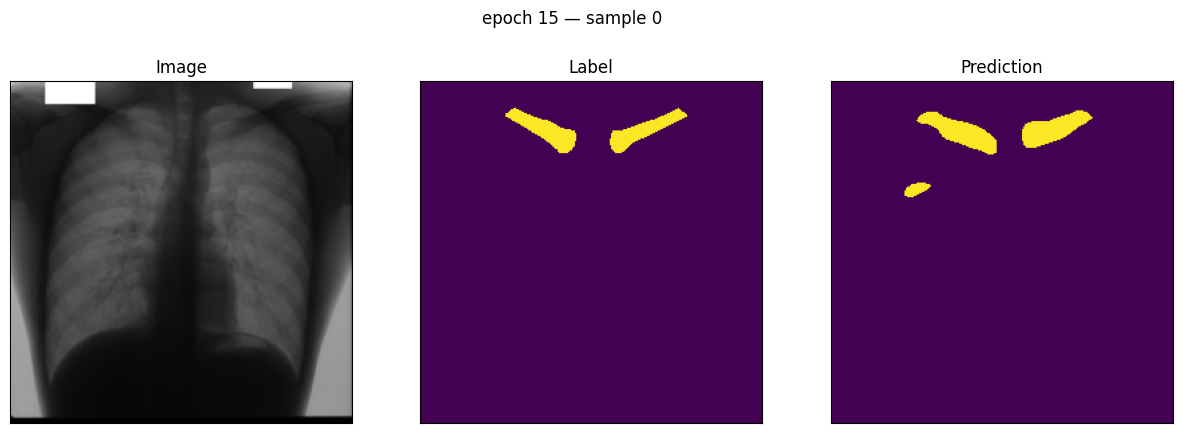

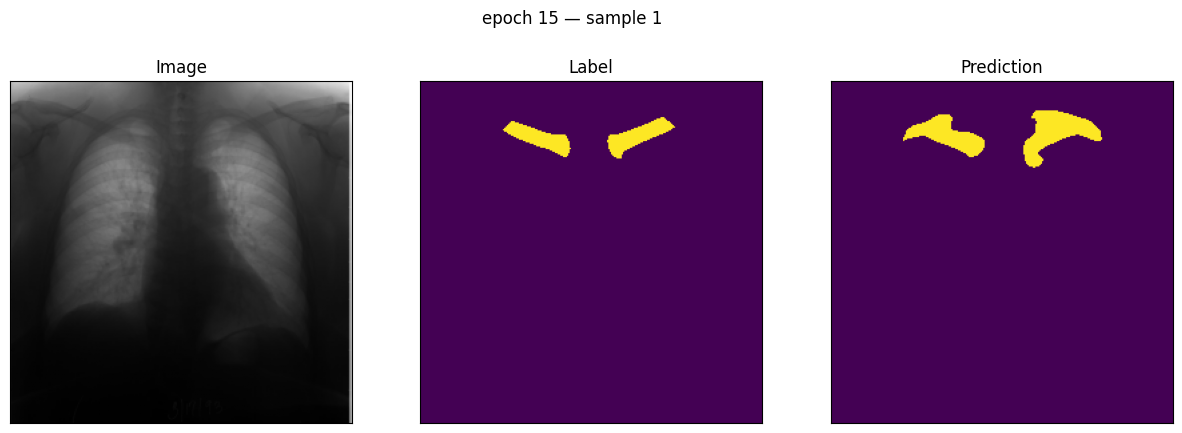

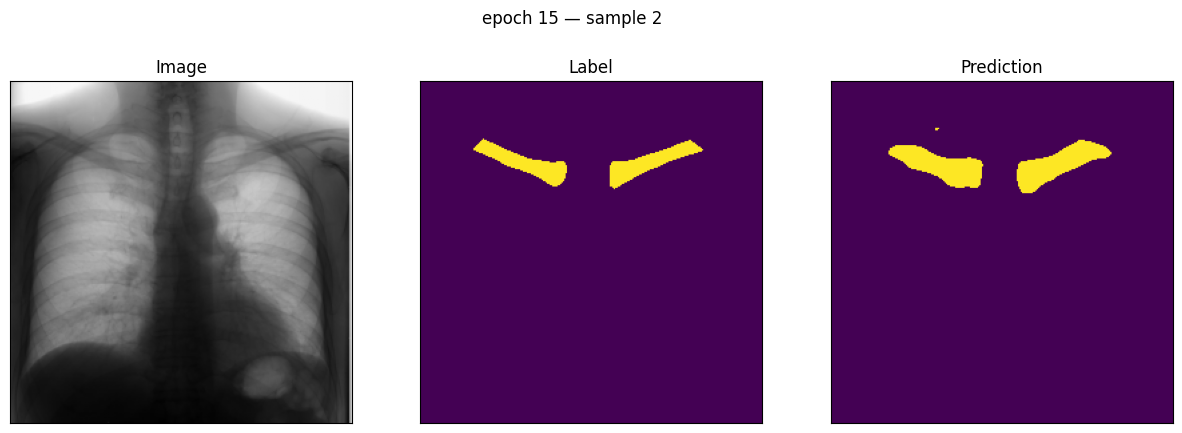

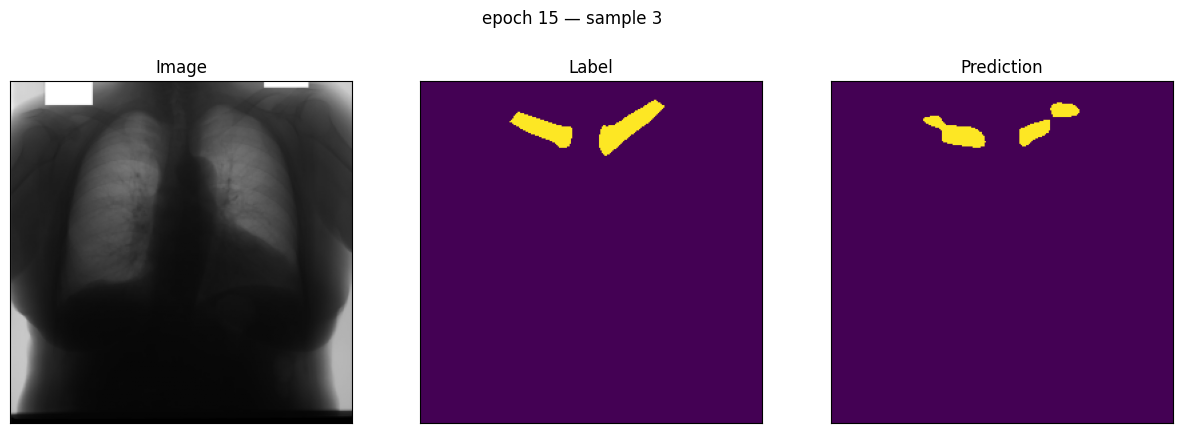

-------------------------------------------------------------------
[epoch 15] [ test loss 0.0428 +/- 0.0138] [iou 0.5762 +/- 0.1366] [f1 0.7202 +/- 0.1266] [time 7.73s]
-------------------------------------------------------------------


train [16]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 16] [train loss 0.0301 +/- 0.0041] [iou 0.6273 +/- 0.0672] [f1 0.7688 +/- 0.0529] [time 190.33s]
-------------------------------------------------------------------


 test [16]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 16] [ test loss 0.0279 +/- 0.0055] [iou 0.5650 +/- 0.1530] [f1 0.7086 +/- 0.1390] [time 7.51s]
-------------------------------------------------------------------


...

 test [19]:   0%|          | 0/50 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 19] [ test loss 0.0263 +/- 0.0076] [iou 0.6193 +/- 0.1263] [f1 0.7566 +/- 0.1080] [time 7.66s]
-------------------------------------------------------------------


train [20]:   0%|          | 0/25 [00:00<?, ?it/s]

-------------------------------------------------------------------
[epoch 20] [train loss 0.0268 +/- 0.0036] [iou 0.6550 +/- 0.0565] [f1 0.7901 +/- 0.0421] [time 176.75s]
-------------------------------------------------------------------


 test [20]:   0%|          | 0/50 [00:00<?, ?it/s]

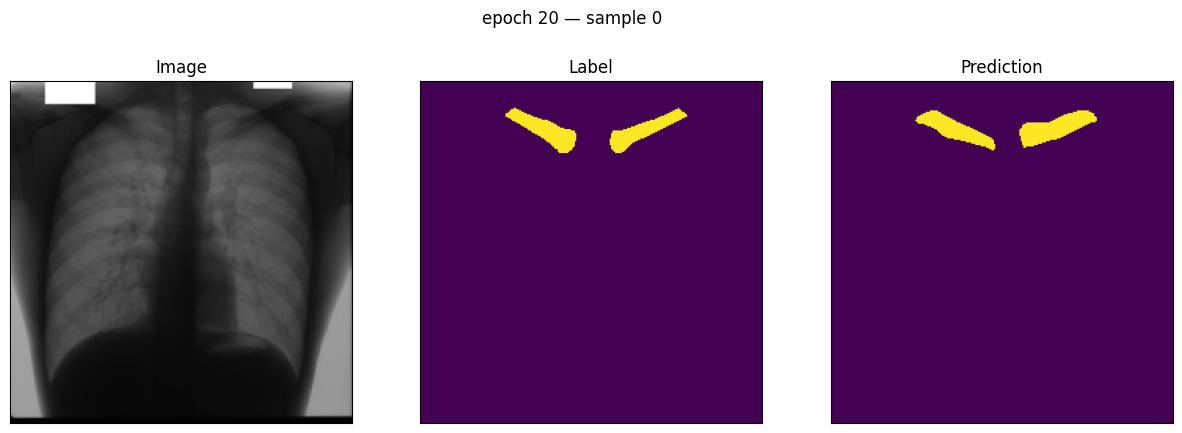

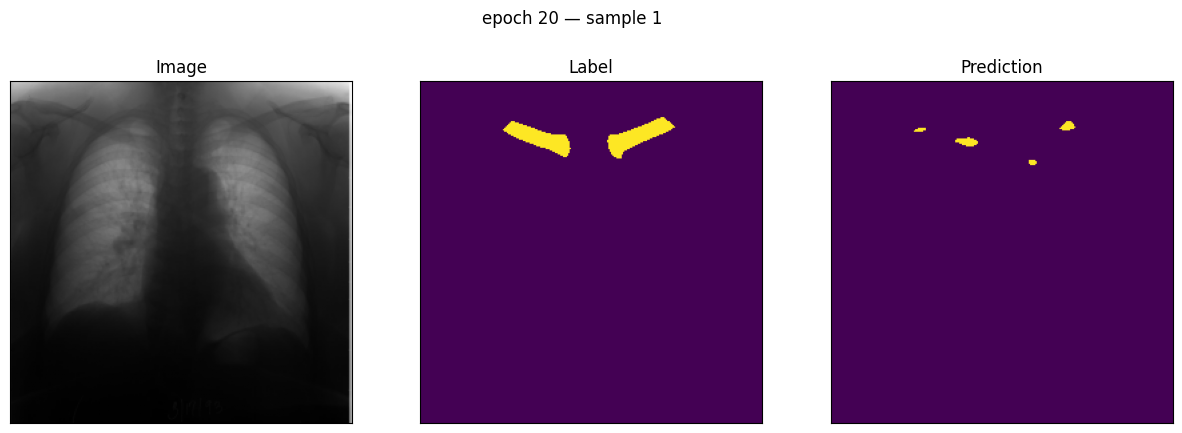

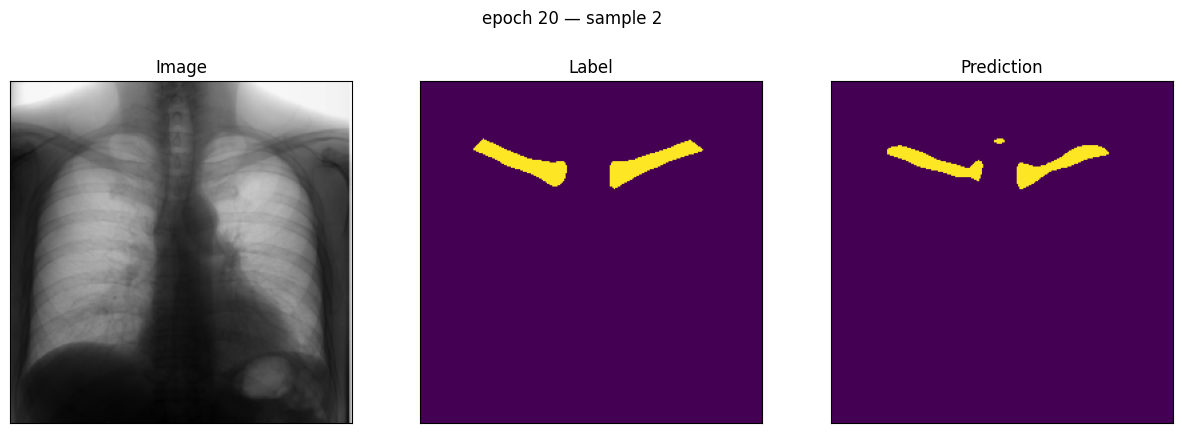

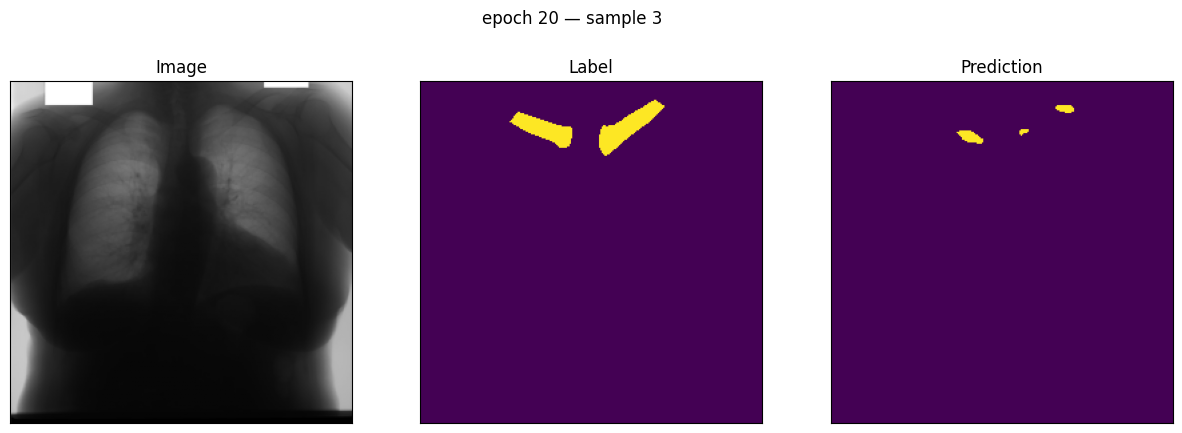

-------------------------------------------------------------------
[epoch 20] [ test loss 0.0264 +/- 0.0090] [iou 0.5960 +/- 0.1869] [f1 0.7249 +/- 0.1902] [time 7.59s]
-------------------------------------------------------------------


In [20]:
history = {"train": [], "test": []}

for epoch in range(1, config["epoch_num"] + 1):
    history["train"].append(train(train_loader, net, criterion, optimizer, epoch, device))
    history["test"].append(
        test(test_loader, net, criterion, epoch, device, show_freq=config["show_freq"])
    )


## Discussion

The numbers below are taken from the 20-epoch run of this notebook on the
**clavicles** task (`pretrained=True`, `skip=True`, `lr=1e-4`,
`batch_size=8`, image size 256x256, CPU).

### Dataset organisation and extending to other anatomical targets

After unzipping, `./jsrt/` contains a single `images/` directory shared
across all tasks and a per-target `ground_truths/<task>/` subdirectory
(`clavicles`, `lungs`, `heart`). Each task has its own
`<task>_train.txt` / `<task>_test.txt` manifest, so the same 154 source
radiographs are reused across three independent foreground/background
problems. Switching targets is a one-line change to `config['task']`
followed by re-running from the data-loader cell, no retraining
infrastructure changes are needed because the network has a fixed
2-class head.

### Convergence behaviour at 5, 10, and 20 epochs

| epoch | train loss | train IoU | train F1 | test loss | test IoU | test F1 |
|------:|-----------:|----------:|---------:|----------:|---------:|--------:|
|   1   | 0.4397     | 0.0507    | 0.0958   | 0.2886    | 0.0102   | 0.0194  |
|   5   | 0.0828     | 0.2695    | 0.4173   | 0.0696    | 0.1795   | 0.2821  |
|  10   | 0.0455     | 0.5061    | 0.6682   | 0.0436    | 0.5489   | 0.7014  |
|  15   | 0.0311     | 0.6164    | 0.7612   | 0.0428    | 0.5762   | 0.7202  |
|  20   | 0.0268     | 0.6550    | 0.7901   | 0.0264    | 0.5960   | 0.7249  |

By epoch 5 the loss has already dropped by roughly 5x but the model is
still essentially failing on the test split (IoU 0.18, F1 0.28), the
network is producing plausible-looking activations but has not yet
learned the clavicle shape prior well enough to generalise. The biggest
single-epoch jump happens around epoch 10, where test IoU climbs from
~0.18 to **0.55** (Dice 0.70). From epoch 10 onwards train and test
metrics rise together, with test IoU peaking at **0.6193 / Dice 0.7566
at epoch 19** before settling to 0.5960 / 0.7249 at epoch 20. The
train–test IoU gap at 20 epochs is ~6 percentage points (0.655 vs
0.596), which is modest given the dataset has only ~150 images, and
test loss has plateaued (with some run-to-run noise around epochs
14–15), suggesting that 20 epochs is roughly where extra training
stops paying off on this split, and that further gains likely require
augmentation or a stronger backbone rather than longer schedules.

The qualitative panels also reveal that the **mean IoU hides a strongly
bimodal per-image distribution**: at epoch 20 the high test-IoU std
(±0.187) corresponds to some test images being almost solved (clean,
tight clavicle shapes, e.g. samples 0 and 2 in the epoch-20 panel)
while others regress to fragmented specks (samples 1 and 3). So the
0.60 average is not "moderate quality on every image" but rather
"good on a subset, poor on a subset", a signal that the failure mode
is per-image (likely correlated with patient anatomy / image
contrast) rather than a uniform under-fit.

### Architectural trade-offs: FCN vs U-Net / SegNet

This FCN-AlexNet is cheap (only ~2.7M trainable parameters and ~3
minutes per epoch on CPU) and reaches a respectable Dice ~0.72 on
clavicles, but its decoder is just bilinear upsampling followed by a
small 3x3 head, it cannot reconstruct fine boundary detail, which
matters most for thin structures like the clavicles themselves. A
**U-Net** would replace that with a symmetric encoder/decoder and
dense skip connections at every resolution, preserving high-frequency
information and typically lifting Dice on JSRT-style problems by
several points, at the cost of more parameters and a more expensive
forward pass. **SegNet** sits in between: it reuses pooling indices
from the encoder for unpooling instead of learning the upsampling
filters, which keeps the parameter count down while still injecting
spatial detail back into the decoder. For a small dataset like JSRT
the FCN is a reasonable starting point, but I would expect U-Net to
win on the clavicles task specifically, where the lung/heart tasks, 
larger, smoother regions, would benefit less from the extra decoder
capacity.

### Spatial reconstruction in FCN-AlexNet

AlexNet's features stage takes the input down by a factor of 32, so
for 256x256 inputs the deepest feature map is 8x8x256. The forward
pass uses `F.interpolate(..., mode='bilinear', align_corners=False)`
to lift those features back to the input resolution before the
classifier head. With `skip=True`, two feature maps are upsampled
independently and concatenated on the channel axis: a mid-level
192-channel map (output of `feat[5]`) and the deep 256-channel map
(output of `feat[12]`), giving a 448-channel input to the head via
`torch.cat([...], dim=1)`. The classifier is a 3x3 conv → BN → ReLU →
Dropout2d → 3x3 conv that produces per-pixel logits at the original
spatial resolution. This is an FCN-8s-style fusion adapted to
AlexNet's depth, and it is what makes the +shallow features visible
in the qualitative panels, without it, the decoder only sees the 8x8
deep map and boundaries come out noticeably blurrier.
